In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Llamamos y observamos los primeros registros de nuestra tabla

In [3]:
base = pd.read_csv('atus_anual_2025.csv')
base.head()

,COBERTURA,CVEGEO,CVE_ENT,CVE_MUN,ANIO,MES,ID_HORA,ID_MINUTO,ID_DIA,DIASEMANA,...,PEATMUERTO,PEATHERIDO,CICLMUERTO,CICLHERIDO,OTROMUERTO,OTROHERIDO,NEMUERTO,NEHERIDO,CLASACC,ESTATUS
0,Municipal,1001,1,1,2025,1,3,30,1,Miércoles,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas
1,Municipal,1001,1,1,2025,1,8,15,1,Miércoles,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas
2,Municipal,1001,1,1,2025,1,8,35,1,Miércoles,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas
3,Municipal,1001,1,1,2025,1,9,35,1,Miércoles,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas
4,Municipal,1001,1,1,2025,1,13,5,1,Miércoles,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas


### Punto 1

In [10]:
# vemos que columnas tiene nuestra base, así como su tipo de dato
inspeccion = pd.DataFrame({'Columna':base.columns,
                        'Tipo de dato':base.dtypes}).reset_index(drop=True)

inspeccion

,Columna,Tipo de dato
0,COBERTURA,object
1,CVEGEO,int64
2,CVE_ENT,int64
3,CVE_MUN,int64
4,ANIO,int64
5,MES,int64
6,ID_HORA,int64
7,ID_MINUTO,int64
8,ID_DIA,int64
9,DIASEMANA,object


In [12]:
# Inspeccionamos los tipos de datos unicos que tiene la columna de 'CLASACC' y 'MOTOCICLET'

print(f'la columna "CLASACC" tiene como elementos unicos a: {base['CLASACC'].unique()}')
print(f'la columna "CLASACC" es del tipo: {base['CLASACC'].dtype}')
print(f'la columna "MOTOCICLET" tiene como elementos unicos a: {base['MOTOCICLET'].unique()}')
print(f'la columna "MOTOCICLET" es del tipo: {base['MOTOCICLET'].dtype}')

la columna "CLASACC" tiene como elementos unicos a: ['Sólo daños' 'No fatal' 'Fatal']
la columna "CLASACC" es del tipo: object
la columna "MOTOCICLET" tiene como elementos unicos a: [0 1 2 3]
la columna "MOTOCICLET" es del tipo: int64


Notamos que 'CLASACC' tiene sólo 3 tipos de variables y son del tipo str, mientras que 'MOTOCICLET' tiene 4 valores unicos y son del tipo numerico.

Vemos que cada registro de la base constituye un accidente que se guardo en la base, por lo que para determinar los eventos V (evento que tuvo al menos una victima) y el evento M (evento que involucro al menos una motocicleta) será aplicar filtros para sólo quedarnos con dichos registros que cumplan esas condiciones, es decir, para el evento V nos quedamos con aquellos registros que tengan en la columna 'CLASACC', 'Fatal' y 'No fatal', mientras que para el evento M, nos quedamos con aquellos registro que tengan en la columna 'MOTOCICLET', 1,2 o 3.

In [ ]:
no_evento_V = len(base[(base['CLASACC'] == 'No fatal') | (base['CLASACC'] == 'Fatal')])
no_evento_M = len(base[base['MOTOCICLET'].isin([1, 2, 3])])
casos_totales = len(base)
print(f'el evento V tuvo un total de {no_evento_V} registros')
print(f'el evento M tuvo un total de {no_evento_M} registros')
print(f'la base tiene un total de {casos_totales} registros')

el evenvto V tuvo un total de 69847 registros
el evenvto M tuvo un total de 88635 registros
la base tiene un total de 380391 registros


### Punto 2

Para calcular las probabilidades de P(V), P(M) y P(VnM) será através de contar los casos favorables entre los casos totales

In [19]:
P_V = no_evento_V / casos_totales
P_M = no_evento_M / casos_totales

Para calcular la probabilidad de la intersección de V y M debemos de aplicar los dos filtros de V y M al mismo tiempo

In [20]:
no_V_n_M = len(base[
                    ((base['CLASACC'] == 'No fatal') | (base['CLASACC'] == 'Fatal')) & 
                    (base['MOTOCICLET'].isin([1, 2, 3]))
            ])
P_V_n_M = no_V_n_M / casos_totales

print(f'la probabilidad que suceda el evento V es de {round(P_V,4)*100}%')
print(f'la probabilidad que suceda el evento M es de {round(P_M,4)*100}%')
print(f'la probabilidad que suceda el evento V y el evento M a la vez es de {round(P_V_n_M,4)*100}%')

la probabilidad que suceda el evento V es de 18.360000000000003%
la probabilidad que suceda el evento M es de 23.3%
la probabilidad que suceda el evento V y el evento M a la vez es de 10.280000000000001%


Esto nos quiere decir que si un accidente ocurre tiene una probabilidad del 18.36% de que tenga al menos una victima, también que tiene una probabilidad del 23.3% que este involucrado al menos una motocicleta, y tiene una probabilidad del 10.28% que el accidente haya tenido al menos una victima y una moto involucrada

### Punto 3

Para calcular la P(V|M) necesitamos la probabilidad de la intersección de V y M y la probabilidad de M, para determinar la probabilidad condicional.

In [21]:
P_V_dado_M = P_V_n_M / P_M
print(f'Por lo que la probabilidad de que haya al menos un herido dado que el accidente involucro una moto es de: {P_V_dado_M}')

Por lo que la probabilidad de que haya al menos un herido dado que el accidente involucro una moto es de: 0.44102216957183954


### Punto 4

Calcularemos P(VnM) numericamente y estará denotado como:

P_1(VnM) = P(V|M) * P(M)

P_2(VnM) = P(M|V) * P(V)

pero primero calcularemos P(M|V), con la definición es decir: P(M|V) = P(MnV)/P(V), sabiendo que P(MnV) = P(VnM)

In [22]:
P_M_dado_V = P_V_n_M/P_V
P_1_V_n_M = P_V_dado_M * P_M
P_2_V_n_M = P_M_dado_V * P_V
print(f'la primera forma de calcular P(VnM) nos da {P_1_V_n_M} y la segunda nos da {P_2_V_n_M}')

la primera forma de calcular P(VnM) nos da 0.10276268365970803 y la segunda nos da 0.10276268365970805


Notamos practicamente que las dos formas de calcular la probabilidad de P(VnM) es practimente la misma.

La diferencia entre P(M|V) y P(V|M) es que la primera calcula la probabilidad de que el accidente hubo al menos una moto, sabiendo que tuvo al menos una victima y la segunda calcula la probabilidad de que si hubo al menos una victima sabiendo que hubo al menos una moto involucrada.

### Punto 5

Para calcular P1(V) = P(V|M) P(M) + P(V|MC) P(MC), en este caso la denotaremos como P1(V) para diferenciarla de P(V)notamos que necesitamos el evento MC que es el complemento del evento M, por lo que MC representaria el evento que no involucre a ninguna motocicleta, para ello tomamos el complemento del evento M (que seria el total - evento M) y sacamos su probabilidad, y para la probabilidad condicional necesitamos la intersección del evento V con MC.

In [27]:
no_evento_MC = casos_totales - no_evento_M
P_MC = no_evento_MC / casos_totales # otra forma -> P_MC = 1 - P_M

no_V_n_MC = len(base[
    ((base['CLASACC'] == 'No fatal') | (base['CLASACC'] == 'Fatal')) & 
    ~(base['MOTOCICLET'].isin([1, 2, 3]))
    ])

P_V_n_MC = no_V_n_MC / casos_totales
P_V_dado_MC = P_V_n_MC / P_MC

P_1_V = P_V_dado_M * P_M + P_V_dado_MC * P_MC

print(f'La probabilidad del evento V calculada con la regla de la probabilidad total es de {P_1_V}, mientras que calculada mediante frecuencia relativa es de {P_V}')

La probabilidad del evento V calculada con la regla de la probabilidad total es de 0.18361896049065302, mientras que calculada mediante frecuencia relativa es de 0.18361896049065304


Practicamente ambas son la misma probabilidad

### Punto 6

El teorema de Bayes nos indica que P1(M|V) = P(V|M) * P(M) / P(V), se denotará así para diferenciarlo de la primera forma que lo definimos que fue con la definición de probabilidad condicional

In [28]:
P_1_M_dado_V = (P_V_dado_M * P_M)/P_V

print(f'La probabilidad de M dado V por la regla de Bayes es {P_1_M_dado_V}, mediante la definicion de probabilidad condicional es {P_M_dado_V}')

La probabilidad de M dado V por la regla de Bayes es 0.559651810385557, mediante la definicion de probabilidad condicional es 0.559651810385557


Ambas probabilidades resultaron iguales

### Punto 7

In [ ]:
# filtramos la tabla para cada evento, pero nos quedamos con un arreglo booleano, donde nos indique si se cumplio el evento o no
evento_V = (base['CLASACC'] == 'No fatal') | (base['CLASACC'] == 'Fatal')
evento_M = base['MOTOCICLET'].isin([1, 2, 3])

# y la normalizamos por fila mediante el parametro normaliza de pd.crosstab e index para que sea por fila
tabla_condicional = pd.crosstab(index=evento_M, columns=evento_V, normalize='index')

print("Tabla de contingencia normalizada:")
tabla_condicional


Tabla de contingencia normalizada:


CLASACC,False,True
MOTOCICLET,,
False,0.894580,0.105420
True,0.558978,0.441022


In [ ]:
# recordamos las probabilidades que ya sabiamos
print(f'la probabilidad de V dado M es de {P_V_dado_M}')
print(f'la probabilidad de V dado MC es de {P_V_dado_MC}')

la probabilidad de V dado M es de 0.44102216957183954
la probabilidad de V dado MC es de 0.10542028270198384


Notamos que la P(V|M) se encuentra en la esquina inferior derecha, mientras que la P(V|MC) esta en la esquina superior derecha, eso significa que la P(VC|M) esta en la esquina inferior izquierda, mientras que la P(VC|MC) esta en la esquina superior izquierda, eso significa que si queremos saber la probabilidad dada la condición, primero localizamos la condición que estará en la fila y posteriormente localizamos lo siguiente en la columna

In [ ]:
# renombramos
tabla_condicional.index = ['Sin Moto (MC)', 'Con Moto (M)']
tabla_condicional.columns = ['Sin Víctima (VC)', 'Con Víctima (V)']

print("Tabla de contingencia normalizada:")
tabla_condicional

Tabla de contingencia normalizada:


,Sin Víctima (VC),Con Víctima (V)
Sin Moto (MC),0.894580,0.105420
Con Moto (M),0.558978,0.441022


In [ ]:
# verificamos la suma de las fila que den 1
suma_filas = tabla_condicional.sum(axis=1)
print("Suma de las probabilidades por fila:")
print(suma_filas)

Suma de las probabilidades por fila:
Sin Moto (MC)    1.0
Con Moto (M)     1.0
dtype: float64


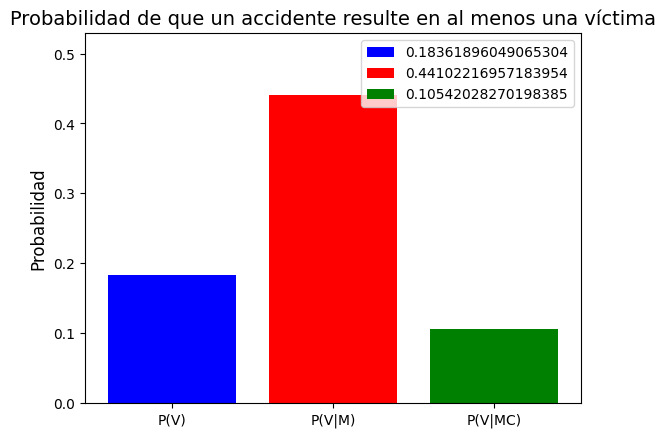

In [ ]:
# Extraemos las probabilidades de la tablade contingencia
P_V_dado_M_t = tabla_condicional.loc['Con Moto (M)', 'Con Víctima (V)']
P_V_dado_MC_t = tabla_condicional.loc['Sin Moto (MC)', 'Con Víctima (V)']

etiquetas = ['P(V)', 'P(V|M)', 'P(V|MC)']
valores = [P_V, P_V_dado_M_t, P_V_dado_MC_t]

plt.bar(etiquetas, valores, color=['blue', 'red', 'green'], label=valores)
plt.title('Probabilidad de que un accidente resulte en al menos una víctima', fontsize=14)
plt.ylabel('Probabilidad', fontsize=12)
plt.ylim(0, max(valores) * 1.2) 

plt.legend()
plt.show()

La gráfica nos muestra visualmente que, a nivel nacional en 2025, un accidente de tráfico cualquiera tiene la probabilidad de tener una victima P(V) del 0.18, pero al calcular, la probabilidad de que si vas en moto y tienes un accidente, la probabilidad de tener una victima sube al 0.44, esto nos indica que el factor de tener una moto, aumenta el riesgo de tener una victima en un accidente.

### Punto 8

In [ ]:
no_evento_F = len(base[base['DIASEMANA'].isin(['Sabado', 'Domingo'])])
